# Token Count Analysis — Qwen 3.5 9B Base

Notebook ini menghitung jumlah token untuk dataset di `standardized/clean` menggunakan **tokenizer Qwen 3.5 - 9B - Base** (via Hugging Face `transformers`).

Analisis yang dihasilkan:
- **Per-sample**: token `system_prompt`, `user_prompt`, `assistant_response`, dan total.
- Agregasi **by task**, **by subject (Mapel)**, **by level (Target)**, dan **by chunk**.
- Visualisasi: bar chart, box plot, heatmap, dan diagram hierarki (sunburst).

## Definisi dimensi
- **Task**: diambil dari nama folder (`essay`, `flashcard`, `materi`, `mindmap`, `pilgan`, `pretest`) berdasarkan file `*_all_merged.json`.
- **Subject**: di-*parse* dari baris `Mapel: ...` pada `user_prompt` (fallback: nama file).
- **Level**: di-*parse* dari `Target: LOTS/MOTS/HOTS` pada `user_prompt`. Jika tidak ada, akan di-*infer* dari pola `LEVEL:` (atau diberi label `MIXED/UNKNOWN`).
- **Chunk**: tidak tersimpan eksplisit di data; di-*infer* sebagai **jumlah paragraf** pada segmen `--- MATERI ---` (antara marker `--- MATERI ---` dan `[TASK]`).

> Catatan: token count tergantung cara serialisasi `assistant_response` (di sini memakai `json.dumps(..., ensure_ascii=False)`). Jika pipeline training Anda memakai format lain (indentasi berbeda / chat template), angka token bisa sedikit berbeda.

In [2]:
# Install dependencies (only if missing)
import importlib
import subprocess
import sys

required = [
    'pandas',
    'tqdm',
    'numpy',
    'transformers',
    'sentencepiece',
    'tiktoken',
    'matplotlib',
    'seaborn',
    'plotly',
    'nbformat',
]

missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
    except Exception:
        missing.append(pkg)

if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
else:
    print('All dependencies already installed.')

All dependencies already installed.


In [3]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_theme(style='whitegrid')

# Resolve project root robustly (works whether cwd is repo root or notebooks/)
cwd = Path.cwd().resolve()
if (cwd / 'standardized').exists():
    ROOT = cwd
elif (cwd.parent / 'standardized').exists():
    ROOT = cwd.parent
else:
    raise RuntimeError(f'Cannot find project root from cwd={cwd}')

CLEAN_DIR = ROOT / 'standardized' / 'clean'
assert CLEAN_DIR.exists(), f'Missing {CLEAN_DIR}'

TASKS = ['essay', 'flashcard', 'materi', 'mindmap', 'pilgan', 'pretest']
DATA_FILES = [CLEAN_DIR / t / f'{t}_all_merged.json' for t in TASKS]
for p in DATA_FILES:
    if not p.exists():
        raise FileNotFoundError(p)

MODEL_NAME_OR_PATH = 'Qwen/Qwen3.5-9B-Base'
# If you have a local tokenizer folder, set it like:
# MODEL_NAME_OR_PATH = str(ROOT / 'models' / 'Qwen3.5-9B-Base')

In [4]:
from transformers import AutoTokenizer

# Load tokenizer (trust_remote_code is commonly required for Qwen tokenizers)
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH, trust_remote_code=True)
except Exception as e:
    raise RuntimeError(
        'Failed to load tokenizer. If you are offline, please ensure the model is cached locally, '
        'or set MODEL_NAME_OR_PATH to a local path. Original error: ' + str(e)
    )

print('Tokenizer loaded:', getattr(tokenizer, 'name_or_path', 'unknown'))

Tokenizer loaded: Qwen/Qwen3.5-9B-Base


In [5]:
# ---------- Parsing helpers ----------

RE_MAPEL = re.compile(r'Mapel:\s*([^|\n]+)')
RE_BAB = re.compile(r'Bab:\s*([^|\n]+)')
RE_SUB_BAB = re.compile(r'Sub Bab:\s*([^|\n]+)')
RE_TARGET = re.compile(r'Target:\s*(LOTS|MOTS|HOTS)\b')

def extract_first(pattern: re.Pattern[str], text: str) -> str | None:
    m = pattern.search(text or '')
    return m.group(1).strip() if m else None

def extract_material_block(user_prompt: str) -> str | None:
    if not user_prompt:
        return None
    start = user_prompt.find('--- MATERI ---')
    if start < 0:
        return None
    after = user_prompt[start + len('--- MATERI ---'):]
    end = after.find('[TASK]')
    block = after[:end] if end >= 0 else after
    block = block.strip()
    return block if block else None

def infer_material_chunk_count(user_prompt: str) -> int:
    block = extract_material_block(user_prompt)
    if not block:
        return 0
    # Paragraphs split by one-or-more blank lines
    paras = [p.strip() for p in re.split(r'\n\s*\n+', block) if p.strip()]
    return len(paras)

def infer_target_level(user_prompt: str) -> str:
    if not user_prompt:
        return 'UNKNOWN'

    target = extract_first(RE_TARGET, user_prompt)
    if target:
        return target

    # If prompt explicitly defines multiple LEVEL blocks, treat as mixed
    levels = re.findall(r'^LEVEL:\s*(LOTS|MOTS|HOTS)\b', user_prompt, flags=re.MULTILINE)
    uniq = list(dict.fromkeys(levels))
    if len(uniq) == 1:
        return uniq[0]
    if len(uniq) > 1:
        return 'MIXED'

    # Heuristic: distribution mention
    if re.search(r'distribusi\s+soal|70%|20%|10%', user_prompt, flags=re.IGNORECASE):
        return 'MIXED'

    return 'UNKNOWN'

def assistant_to_text(assistant_response) -> str:
    if assistant_response is None:
        return ''
    if isinstance(assistant_response, str):
        return assistant_response
    # Serialize dict/list into JSON string
    return json.dumps(assistant_response, ensure_ascii=False)

def count_tokens(text: str) -> int:
    if not text:
        return 0
    # add_special_tokens=False so counts reflect raw content
    return len(tokenizer.encode(text, add_special_tokens=False))

In [6]:
# ---------- Load data & compute per-sample token counts ----------

rows = []

for task, path in zip(TASKS, DATA_FILES):
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)

    for i, sample in enumerate(tqdm(data, desc=f'[{task}] {path.name}')):
        system_prompt = (sample or {}).get('system_prompt', '')
        user_prompt = (sample or {}).get('user_prompt', '')
        assistant_resp = (sample or {}).get('assistant_response', None)

        subject = extract_first(RE_MAPEL, user_prompt)
        bab = extract_first(RE_BAB, user_prompt)
        sub_bab = extract_first(RE_SUB_BAB, user_prompt)
        target_level = infer_target_level(user_prompt)
        material_chunks = infer_material_chunk_count(user_prompt)

        assistant_text = assistant_to_text(assistant_resp)

        tok_system = count_tokens(system_prompt)
        tok_user = count_tokens(user_prompt)
        tok_assistant = count_tokens(assistant_text)

        rows.append({
            'sample_id': f'{task}-{i:06d}',
            'task': task,
            'source_file': str(path.relative_to(ROOT)),
            'subject': subject or 'UNKNOWN',
            'bab': bab or 'UNKNOWN',
            'sub_bab': sub_bab or 'UNKNOWN',
            'level': target_level,
            'material_chunk_count': material_chunks,
            'assistant_items': (len(assistant_resp) if isinstance(assistant_resp, list) else (1 if assistant_resp is not None else 0)),
            'tokens_system': tok_system,
            'tokens_user': tok_user,
            'tokens_assistant': tok_assistant,
            'tokens_total': tok_system + tok_user + tok_assistant,
        })

df = pd.DataFrame(rows)
df.head()

[pretest] pretest_all_merged.json: 100%|██████████| 194/194 [00:02<00:00, 90.48it/s] 


,sample_id,task,source_file,subject,bab,sub_bab,level,material_chunk_count,assistant_items,tokens_system,tokens_user,tokens_assistant,tokens_total
0,essay-000000,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Belajar Menjadi Negosiator Ulung,Memahami Unsur Kebahasaan dalam Teks Negosiasi,HOTS,1,5,388,493,1687,2568
1,essay-000001,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Belajar Menjadi Negosiator Ulung,Memahami Unsur Kebahasaan dalam Teks Negosiasi,HOTS,2,5,388,709,2476,3573
2,essay-000002,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Belajar Menjadi Negosiator Ulung,Memahami Unsur Kebahasaan dalam Teks Negosiasi,HOTS,3,5,388,705,2267,3360
3,essay-000003,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Belajar Menjadi Negosiator Ulung,Memahami Unsur Kebahasaan dalam Teks Negosiasi,LOTS,1,5,388,478,2530,3396
4,essay-000004,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Belajar Menjadi Negosiator Ulung,Memahami Unsur Kebahasaan dalam Teks Negosiasi,LOTS,2,5,388,694,1411,2493


In [7]:
# Quick overview

display(df.describe(include='all'))

# Min/max for each token field
token_cols = ['tokens_system', 'tokens_user', 'tokens_assistant', 'tokens_total']
display(df[token_cols].agg(['min', 'max']).T)

print('Total samples:', len(df))
print('Total tokens:', int(df['tokens_total'].sum()))
print('Tokens_total per-sample (min/max/p50/p90/p95/p99):',
      int(df['tokens_total'].min()), '/', int(df['tokens_total'].max()), '/',
      np.percentile(df['tokens_total'], [50, 90, 95, 99]).round(2))

,sample_id,task,source_file,subject,bab,sub_bab,level,material_chunk_count,assistant_items,tokens_system,tokens_user,tokens_assistant,tokens_total
count,2707,2707,2707,2707,2707,2707,2707,2707.000000,2707.000000,2707.0,2707.000000,2707.000000,2707.000000
unique,2707,6,6,3,17,60,5,NaN,NaN,NaN,NaN,NaN,NaN
top,essay-000000,essay,standardized\clean\essay\essay_all_merged.json,Bahasa Indonesia,Sejarah Kerajaan dan Geosfer,Diferensiasi Sosial Budaya,HOTS,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,582,582,1092,271,56,773,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.930920,5.341337,388.0,673.814555,1764.243443,2826.057998
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.827753,3.425083,0.0,205.695495,1623.663215,1607.468270
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,388.0,385.000000,177.000000,1049.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,388.0,503.000000,532.500000,1565.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,5.000000,388.0,622.000000,1288.000000,2489.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,10.000000,388.0,805.500000,2522.500000,3514.000000


,min,max
tokens_system,388,388
tokens_user,385,1363
tokens_assistant,177,14194
tokens_total,1049,15276


Total samples: 2707
Total tokens: 7650139
Tokens_total per-sample (min/max/p50/p90/p95/p99): 1049 / 15276 / [2489.   4546.8  5457.5  9321.76]


,samples,tokens_total_sum,tokens_total_mean,tokens_total_median,tokens_total_min,tokens_total_max
level,,,,,,
HOTS,773,2465712,3189.795602,2677.0,1096,15074
MOTS,773,2319924,3001.195343,2652.0,1096,12595
LOTS,773,1809228,2340.527814,2287.0,1049,15276
MIXED,194,752451,3878.613402,3348.0,2836,12026
UNKNOWN,194,302824,1560.948454,1492.0,1076,2556


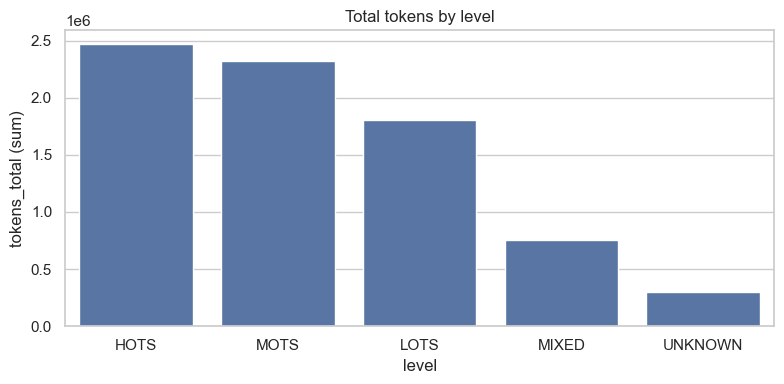

         tokens_total_min  tokens_total_max
level                                      
HOTS                 1096             15074
MOTS                 1096             12595
LOTS                 1049             15276
MIXED                2836             12026
UNKNOWN              1076              2556


In [8]:
# ---------- By level (Target) ----------
level_stats = (
    df.groupby('level')
      .agg(samples=('sample_id', 'count'),
           tokens_total_sum=('tokens_total', 'sum'),
           tokens_total_mean=('tokens_total', 'mean'),
           tokens_total_median=('tokens_total', 'median'),
           tokens_total_min=('tokens_total', 'min'),
           tokens_total_max=('tokens_total', 'max'))
      .sort_values('tokens_total_sum', ascending=False)
)
display(level_stats)

plt.figure(figsize=(8, 4))
sns.barplot(x=level_stats.index, y=level_stats['tokens_total_sum'])
plt.title('Total tokens by level')
plt.ylabel('tokens_total (sum)')
plt.xlabel('level')
plt.tight_layout()
plt.show()

# Show min/max for each level
print(level_stats[['tokens_total_min', 'tokens_total_max']])

In [9]:
# ---------- Min/max summary by group (tokens_total) ----------

print('Min/max by task:')
display(df.groupby('task')['tokens_total'].agg(['min', 'max']))

print('Min/max by subject:')
display(df.groupby('subject')['tokens_total'].agg(['min', 'max']))

print('Min/max by level:')
display(df.groupby('level')['tokens_total'].agg(['min', 'max']))

print('Min/max by material_chunk_count:')
display(df.groupby('material_chunk_count')['tokens_total'].agg(['min', 'max']))

Min/max by task:


,min,max
task,,
essay,1886,12595
flashcard,1049,1804
materi,1575,4222
mindmap,1076,2556
pilgan,2400,15276
pretest,2836,12026


Min/max by subject:


,min,max
subject,,
Bahasa Indonesia,1049,9318
IPS,1076,5877
Matematika Umum,1081,15276


Min/max by level:


,min,max
level,,
HOTS,1096,15074
LOTS,1049,15276
MIXED,2836,12026
MOTS,1096,12595
UNKNOWN,1076,2556


Min/max by material_chunk_count:


,min,max
material_chunk_count,,
1,1049,12634
2,1125,15276
3,1237,11880


,samples,tokens_total_sum,tokens_total_mean,tokens_total_median,tokens_total_min,tokens_total_max
subject,,,,,,
Bahasa Indonesia,1092,2808293,2571.696886,2405.0,1049,9318
Matematika Umum,798,2767941,3468.597744,2789.5,1081,15276
IPS,817,2073905,2538.439412,2362.0,1076,5877


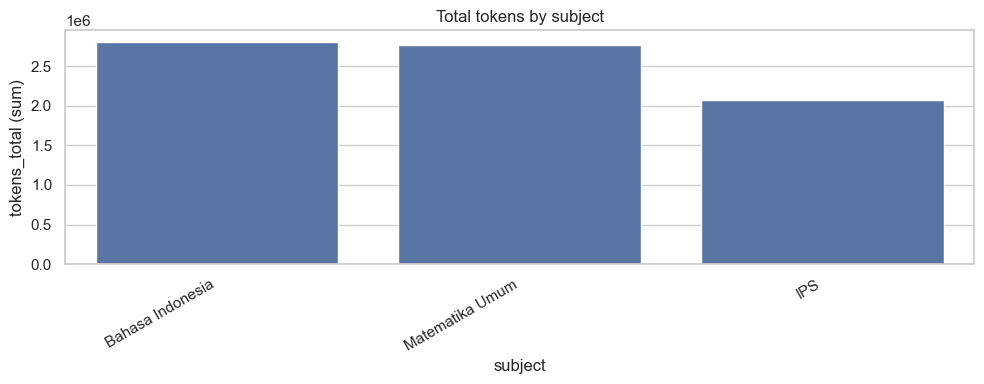

                  tokens_total_min  tokens_total_max
subject                                             
Bahasa Indonesia              1049              9318
Matematika Umum               1081             15276
IPS                           1076              5877


In [10]:
# ---------- By subject (Mapel) ----------
subject_stats = (
    df.groupby('subject')
      .agg(samples=('sample_id', 'count'),
           tokens_total_sum=('tokens_total', 'sum'),
           tokens_total_mean=('tokens_total', 'mean'),
           tokens_total_median=('tokens_total', 'median'),
           tokens_total_min=('tokens_total', 'min'),
           tokens_total_max=('tokens_total', 'max'))
      .sort_values('tokens_total_sum', ascending=False)
)
display(subject_stats)

plt.figure(figsize=(10, 4))
sns.barplot(x=subject_stats.index, y=subject_stats['tokens_total_sum'])
plt.title('Total tokens by subject')
plt.ylabel('tokens_total (sum)')
plt.xlabel('subject')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Show min/max for each subject
print(subject_stats[['tokens_total_min', 'tokens_total_max']])

,samples,tokens_total_sum,tokens_total_mean,tokens_total_median
level,,,,
HOTS,773,2465712,3189.795602,2677.0
MOTS,773,2319924,3001.195343,2652.0
LOTS,773,1809228,2340.527814,2287.0
MIXED,194,752451,3878.613402,3348.0
UNKNOWN,194,302824,1560.948454,1492.0


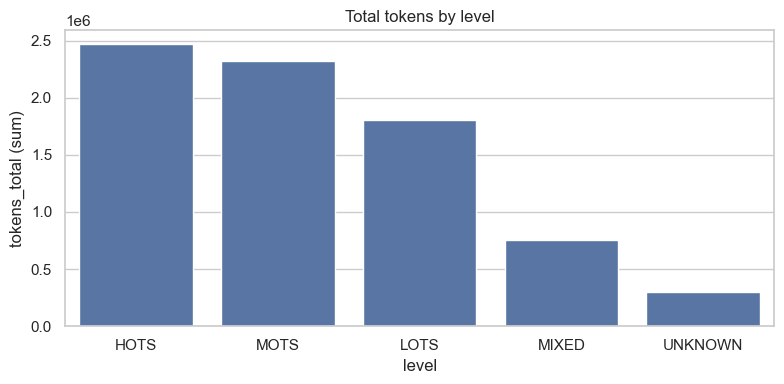

In [ ]:
# ---------- By task ----------
task_stats = (
    df.groupby('task')
      .agg(samples=('sample_id', 'count'),
           tokens_total_sum=('tokens_total', 'sum'),
           tokens_total_mean=('tokens_total', 'mean'),
           tokens_total_median=('tokens_total', 'median'),
           tokens_total_min=('tokens_total', 'min'),
           tokens_total_max=('tokens_total', 'max'))
      .sort_values('tokens_total_sum', ascending=False)
)
display(task_stats)

plt.figure(figsize=(10, 4))
sns.barplot(x=task_stats.index, y=task_stats['tokens_total_sum'])
plt.title('Total tokens by task')
plt.ylabel('tokens_total (sum)')
plt.xlabel('task')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='task', y='tokens_total')
plt.yscale('log')
plt.title('Token distribution by task (log scale)')
plt.ylabel('tokens_total')
plt.xlabel('task')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Show min/max for each task
print(task_stats[['tokens_total_min', 'tokens_total_max']])

,samples,tokens_total_mean,tokens_user_mean,tokens_total_sum
material_chunk_count,,,,
1,1027,2661.666991,576.054528,2733532
2,840,2832.307143,679.467857,2379138
3,840,3020.796429,787.684524,2537469


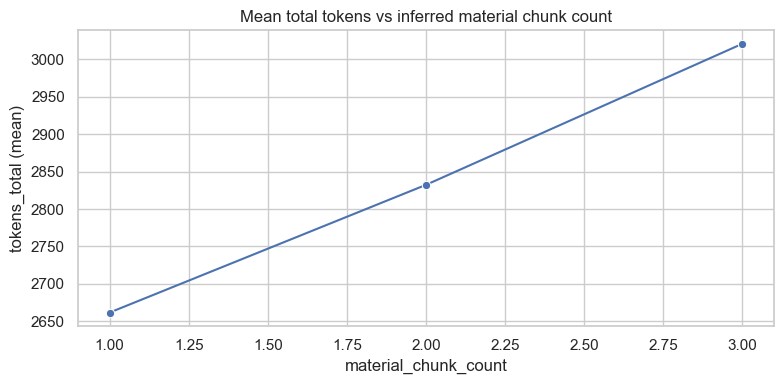

In [ ]:
# ---------- By chunk (inferred material_chunk_count) ----------
chunk_stats = (
    df.groupby('material_chunk_count')
      .agg(samples=('sample_id', 'count'),
           tokens_total_sum=('tokens_total', 'sum'),
           tokens_total_mean=('tokens_total', 'mean'),
           tokens_total_median=('tokens_total', 'median'),
           tokens_total_min=('tokens_total', 'min'),
           tokens_total_max=('tokens_total', 'max'),
           tokens_user_mean=('tokens_user', 'mean'))
      .sort_index()
)
display(chunk_stats)

plt.figure(figsize=(8, 4))
sns.lineplot(data=chunk_stats.reset_index(), x='material_chunk_count', y='tokens_total_mean', marker='o')
plt.title('Mean total tokens vs inferred material chunk count')
plt.ylabel('tokens_total (mean)')
plt.xlabel('material_chunk_count')
plt.tight_layout()
plt.show()

# Show min/max for each chunk count
print(chunk_stats[['tokens_total_min', 'tokens_total_max']])

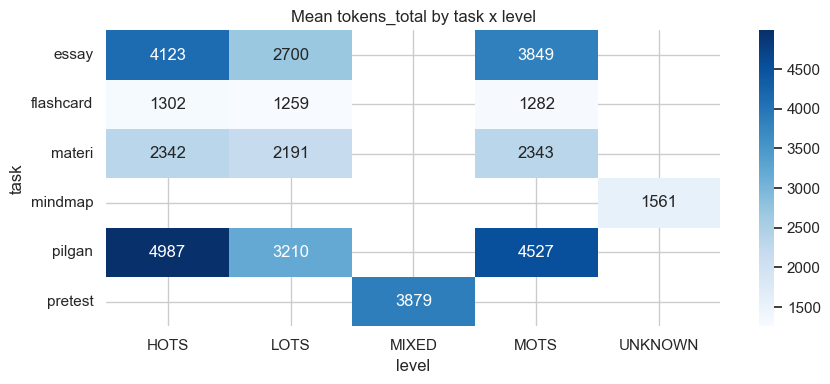

In [ ]:
# ---------- Heatmap: task x level ----------
pivot = df.pivot_table(index='task', columns='level', values='tokens_total', aggfunc='mean')
plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues')
plt.title('Mean tokens_total by task x level')
plt.tight_layout()
plt.show()

In [ ]:
# ---------- Hierarchy diagram (sunburst): task -> subject -> level ----------
grouped = (
    df.groupby(['task', 'subject', 'level'], as_index=False)
      .agg(tokens_total=('tokens_total', 'sum'), samples=('sample_id', 'count'))
)
fig = px.sunburst(
    grouped,
    path=['task', 'subject', 'level'],
    values='tokens_total',
    color='tokens_total',
    color_continuous_scale='Blues',
    title='Token mass by task → subject → level',
)

# Plotly rendering in notebooks needs nbformat
try:
    import nbformat  # noqa: F401
except Exception:
    print('Plotly MIME rendering requires `nbformat`. Re-run the first cell or install with: pip install nbformat')
else:
    fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# ---------- Per-sample (rows) ----------
df_sorted = df.sort_values('tokens_total', ascending=False)
display(df_sorted.head(30))

# Optional: save results for later analysis
OUT_DIR = ROOT / 'output' / 'token_stats'
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / 'token_counts_qwen35_9b_base.csv'
df.to_csv(out_path, index=False)
print('Saved:', out_path)

,sample_id,task,source_file,subject,bab,sub_bab,level,material_chunk_count,assistant_items,tokens_system,tokens_user,tokens_assistant,tokens_total
2400,pilgan-000466,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Barisan dan Deret,Deret,LOTS,2,10,388,694,14194,15276
2496,pilgan-000562,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Sistem Persamaan dan Pertidaksamaan Linear,Sistem Pertidaksamaan Linear,HOTS,2,10,388,678,14008,15074
2415,pilgan-000481,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Eksponen,Fungsi Eksponensial,HOTS,2,10,388,553,12437,13378
2477,pilgan-000543,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Eksponen,Sifat-Sifat Eksponen,HOTS,1,10,388,478,11768,12634
571,essay-000571,essay,standardized\clean\essay\essay_all_merged.json,Matematika Umum,Sistem Persamaan dan Pertidaksamaan Linear,Sistem Pertidaksamaan Linear,MOTS,2,8,388,703,11504,12595
537,essay-000537,essay,standardized\clean\essay\essay_all_merged.json,Matematika Umum,Representasi dan Interpretasi Data,Representasi Data Lanjutan,HOTS,1,10,388,578,11568,12534
2668,pretest-000155,pretest,standardized\clean\pretest\pretest_all_merged....,Matematika Umum,Barisan dan Deret,Deret,MIXED,1,10,388,753,10885,12026
2431,pilgan-000497,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Persamaan dan Fungsi Kuadrat,Fungsi Kuadrat,MOTS,3,10,388,711,10781,11880
2416,pilgan-000482,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Eksponen,Fungsi Eksponensial,HOTS,3,10,388,683,10235,11306
2404,pilgan-000470,pilgan,standardized\clean\pilgan\pilgan_all_merged.json,Matematika Umum,Barisan dan Deret,Deret,MOTS,3,10,388,898,9992,11278


Saved: C:\Local D\Galeri Belajar\Project\SR_02\data_prep_for_sft_v3\output\token_stats\token_counts_qwen35_9b_base.csv
